### Use the Standardized Anomaly method to calculate SWE within EOF weight regions:

In [2]:
import numpy as np 
import pandas as pd 
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
import altair as alt
import pickle
from scipy.linalg import svd
import seaborn as sns

In [3]:
sierras = gpd.read_file('../data/misc/sierra_simplified.geojson')

## Get EOF weights:

### Load reanalysis data and subset to 1 April in snowy regions:

In [4]:
# use open_mfdataset to open all years of swe/sca data at once, then open all sd data at once, and merge the two datasets saving the output file

base_dir = '../swe_reanalysis_pca/data/download'

swe_sca_files = []
sd_files = []

for year in range(1985, 2022):
    year_folder = Path(base_dir) / str(year)
    swe_sca_files.append(f"{base_dir}/{year}/SWE_SCA_POST_{year}.nc")
    sd_files.append(f"{base_dir}/{year}/SD_POST_{year}.nc")

def preprocess_swe(ds):
    ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
    ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
    return ds

swe_sca_ds_allyrs = xr.open_mfdataset(
    swe_sca_files,
    combine='by_coords',
    preprocess=preprocess_swe
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)


sd_ds_allyrs = xr.open_mfdataset(
    sd_files,
    combine='by_coords'
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)

swe_sca_ds_allyrs['SD_Post'] = sd_ds_allyrs['SD_Post']


# swe_sca_ds = swe_sca_ds.rename({'Latitude': 'y', 'Longitude': 'x'})
# swe_sca_ds = swe_sca_ds.rio.set_spatial_dims('y', 'x', inplace=True)
swe_sca_ds_allyrs['SWE_Post'] = swe_sca_ds_allyrs['SWE_Post'].T
swe_sca_ds_allyrs['SCA_Post'] = swe_sca_ds_allyrs['SCA_Post'].T
swe_sca_ds_allyrs = swe_sca_ds_allyrs.transpose('time', 'y', 'x')
swe_sca_ds_allyrs.rio.write_crs('EPSG:4326', inplace=True)
#swe_sca_ds['SD_Post'] = swe_sca_ds['SD_Post'].T

<xarray.Dataset> Size: 287GB
Dimensions:      (time: 13514, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 108kB 1984-10-01 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

### Clip to simplified Sierra gmba polygon:

In [5]:
swe_sca_ds_allyrs_sierras = swe_sca_ds_allyrs.rio.clip(sierras.geometry)

### Get just April 1 of each year from the timeseries:

In [6]:
# 1. Select April 1 of each year
swe_allyrs_april1 = swe_sca_ds_allyrs_sierras.SWE_Post.sel(time=( (swe_sca_ds_allyrs_sierras['time'].dt.month == 4) & (swe_sca_ds_allyrs_sierras['time'].dt.day == 1) )).compute()

/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


In [7]:
swe_allyrs_april1_snowy = swe_allyrs_april1.where(swe_allyrs_april1.mean(dim='time') > 0.1)

### Calculate the standardized anomaly (SA):

In [8]:
swe_allyrs_april1_snowy_anomalies = (swe_allyrs_april1_snowy - swe_allyrs_april1_snowy.mean(dim='time')) / swe_allyrs_april1_snowy.std(dim='time')

### Stack the space dimension and remove nan values:

In [9]:
# Stack spatial dimensions into a single 'space' dimension
swe_2d_anom = swe_allyrs_april1_snowy_anomalies.stack(space=('y', 'x'))

# Optionally, drop all spatial points (columns) that have any NaNs across time
swe_2d_clean_anom = swe_2d_anom.dropna(dim='space', how='any')

# Convert to a numpy 2D array: shape will be (time, space)
swe_2d_array_anom = swe_2d_clean_anom.values

### Run the SVD on the standardized anomalies:

In [10]:
U_anom, S_anom, V_anom = svd(swe_2d_array_anom.T, full_matrices=False)

### Format the spatial matrix with coordinates:

In [11]:
U_spatial_anom = xr.full_like(swe_2d_clean_anom, np.nan)
U_spatial_anom.values = U_anom.T
U_spatial_unstacked_anom = U_spatial_anom.unstack('space')
U_spatial_unstacked_sorted_anom = U_spatial_unstacked_anom.sortby(['y', 'x'])

### Replace the time coordinate with EOF number:

In [13]:
# Replace the 'time' dimension with 'EOF' (1 to N), preserving order
n_eof = U_spatial_unstacked_sorted_anom.sizes['time']
U_spatial_eof_anom = U_spatial_unstacked_sorted_anom.copy()
U_spatial_eof_anom = U_spatial_eof_anom.rename({'time': 'EOF'})
U_spatial_eof_anom = U_spatial_eof_anom.assign_coords(EOF=np.arange(1, n_eof+1))

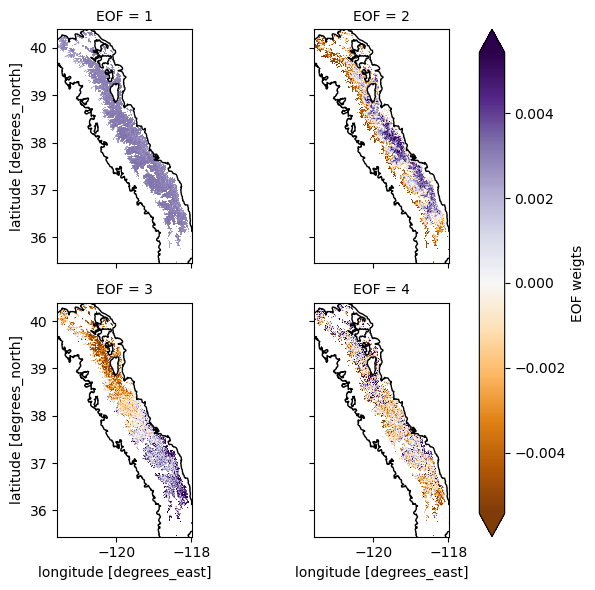

In [45]:
firstFour = U_spatial_eof_anom.isel(EOF=slice(0, 4)).copy()

g = firstFour.plot.pcolormesh(
    x="x",
    y="y",
    col="EOF",
    col_wrap=2,
    robust=True,
    cmap="PuOr",
    cbar_kwargs={"label": "EOF weigts"},
)

# Add sierras polygon to each subplot
for ax in g.axs.flat:
    sierras.boundary.plot(ax=ax, color='black', linewidth=1)

### Access the pre-sampled Reanalysis arrays for each actual icesat2 date and reassign their coordinates:

In [24]:
atl06sr_gdf = pickle.load(open('../data/icesat2/sierras_gdf_2018_2021_sa_processed_masked_fscapresence.pkl', 'rb'))

In [25]:
atl06sr_gdf = atl06sr_gdf.clip(sierras.to_crs(atl06sr_gdf.crs))

In [26]:
atl06sr_gdf['acqdate_dt'] = pd.to_datetime(atl06sr_gdf['acqdate'])

In [15]:
atl06sr_gdf.columns

Index(['segment_watermask', 'segment_snowcover', 'pflags', '3dep.value',
       'region', '3dep.deriv.slope', 'gt', 'n_fit_photons',
       'w_surface_window_final', '3dep.fileid', 'rgt', 'rms_misfit',
       '3dep.deriv.count', '3dep.deriv.aspect', 'h_mean', 'dh_fit_dx', 'x_atc',
       'h_sigma', 'spot', 'y_atc', 'urban_flag', '3dep.time_ns',
       'beam_azimuth', 'srcid', 'segment_landcover', 'cycle', 'photon_start',
       'geometry', 'time', 'slope_count', 'slope', 'aspect', 'file', 'value',
       'time_acq', 'doy', 'decyear', 'dowy', 'acqdate', 'reanalysis_swe',
       'reanalysis_sca', 'reanalysis_sd', 'icesat2_3dep_dif', 'dif_plus',
       'offset_sd', 'mask', 'snow_presence', 'snow_presence_fsca'],
      dtype='object')

Steps to test this method:  
* for our date of interest 17 March, 2019:  
    * make a subset dataframe of the atl06sr_gdf for the highlight date
    * sample EOFs 2 and 3 at the icesat2 points on this date and save the eof weights to the subset dataframe under columns named 'eof2_weights' and 'eof3_weights'
    * Sample the 1985-2021 reanalysis snow depth data on that date of each year, using linear interp
    * add the sampled values to the dataframe, with the column named 'wy_{water_year}'
    

In [27]:
# Define date of interest
date_of_interest = pd.Timestamp('2019-03-17')
current_year = 2019

# 1. Subset atl06sr_gdf to the date of interest
atl06sr_subset = atl06sr_gdf[atl06sr_gdf['acqdate_dt'].dt.date == date_of_interest.date()].copy()

# Get lat/lon coordinates from the geometry
lons = atl06sr_subset.geometry.x.values
lats = atl06sr_subset.geometry.y.values

# 2. Sample EOFs 2 and 3 at the ICESat-2 points using linear interpolation
# Note: EOF indices are 1-based in U_spatial_eof_anom, so EOF 2 and 3 are at indices 2 and 3
eof2_weights = U_spatial_eof_anom.sel(EOF=2).interp(
    x=xr.DataArray(lons, dims='points'),
    y=xr.DataArray(lats, dims='points'),
    method='linear'
).values

eof3_weights = U_spatial_eof_anom.sel(EOF=3).interp(
    x=xr.DataArray(lons, dims='points'),
    y=xr.DataArray(lats, dims='points'),
    method='linear'
).values

atl06sr_subset['eof2_weights'] = eof2_weights
atl06sr_subset['eof3_weights'] = eof3_weights



In [28]:
# 3. Sample reanalysis snow depth data on March 17 for each year (1985-2021, excluding 2019)
for year in range(1985, 2022):
    if year == current_year:
        continue  # Skip the current year (2019)
    
    # Determine the water year (Oct-Sep, so March 2019 is WY 2019)
    water_year = year
    
    # Get the target date for this year (March 17)
    target_date = pd.Timestamp(f'{year}-03-17')
    
    # Select the snow depth data for this date
    sd_on_date = swe_sca_ds_allyrs_sierras['SD_Post'].sel(time=target_date, method='nearest')
    
    # Sample at ICESat-2 points using linear interpolation
    sampled_sd = sd_on_date.interp(
        x=xr.DataArray(lons, dims='points'),
        y=xr.DataArray(lats, dims='points'),
        method='linear'
    ).values
    
    # Add to the dataframe
    atl06sr_subset[f'wy_{water_year}'] = sampled_sd

print(f"Subset dataframe shape: {atl06sr_subset.shape}")
print(f"Number of ICESat-2 points on {date_of_interest.date()}: {len(atl06sr_subset)}")
print(f"Columns added: {[col for col in atl06sr_subset.columns if 'eof' in col or 'wy_' in col]}")

Subset dataframe shape: (24886, 87)
Number of ICESat-2 points on 2019-03-17: 24886
Columns added: ['eof2_weights', 'eof3_weights', 'wy_1985', 'wy_1986', 'wy_1987', 'wy_1988', 'wy_1989', 'wy_1990', 'wy_1991', 'wy_1992', 'wy_1993', 'wy_1994', 'wy_1995', 'wy_1996', 'wy_1997', 'wy_1998', 'wy_1999', 'wy_2000', 'wy_2001', 'wy_2002', 'wy_2003', 'wy_2004', 'wy_2005', 'wy_2006', 'wy_2007', 'wy_2008', 'wy_2009', 'wy_2010', 'wy_2011', 'wy_2012', 'wy_2013', 'wy_2014', 'wy_2015', 'wy_2016', 'wy_2017', 'wy_2018', 'wy_2020', 'wy_2021']


In [39]:
atl06sr_subset.columns

Index(['segment_watermask', 'segment_snowcover', 'pflags', '3dep.value',
       'region', '3dep.deriv.slope', 'gt', 'n_fit_photons',
       'w_surface_window_final', '3dep.fileid', 'rgt', 'rms_misfit',
       '3dep.deriv.count', '3dep.deriv.aspect', 'h_mean', 'dh_fit_dx', 'x_atc',
       'h_sigma', 'spot', 'y_atc', 'urban_flag', '3dep.time_ns',
       'beam_azimuth', 'srcid', 'segment_landcover', 'cycle', 'photon_start',
       'geometry', 'time', 'slope_count', 'slope', 'aspect', 'file', 'value',
       'time_acq', 'doy', 'decyear', 'dowy', 'acqdate', 'reanalysis_swe',
       'reanalysis_sca', 'reanalysis_sd', 'icesat2_3dep_dif', 'dif_plus',
       'offset_sd', 'mask', 'snow_presence', 'snow_presence_fsca',
       'acqdate_dt', 'eof2_weights', 'eof3_weights', 'wy_1985', 'wy_1986',
       'wy_1987', 'wy_1988', 'wy_1989', 'wy_1990', 'wy_1991', 'wy_1992',
       'wy_1993', 'wy_1994', 'wy_1995', 'wy_1996', 'wy_1997', 'wy_1998',
       'wy_1999', 'wy_2000', 'wy_2001', 'wy_2002', 'wy_2003',

In [50]:
atl06sr_subset['snow_presence']

time_ns
2019-03-17 16:05:58.552339968    1
2019-03-17 16:05:58.555159552    1
2019-03-17 16:05:58.979812608    1
2019-03-17 16:05:58.982648320    1
2019-03-17 16:05:58.985481728    1
                                ..
2019-03-17 16:06:40.331458560    1
2019-03-17 16:06:40.334267392    1
2019-03-17 16:06:40.337075200    1
2019-03-17 16:06:40.339883776    1
2019-03-17 16:06:40.342691840    1
Name: snow_presence, Length: 24886, dtype: int64

<Axes: >

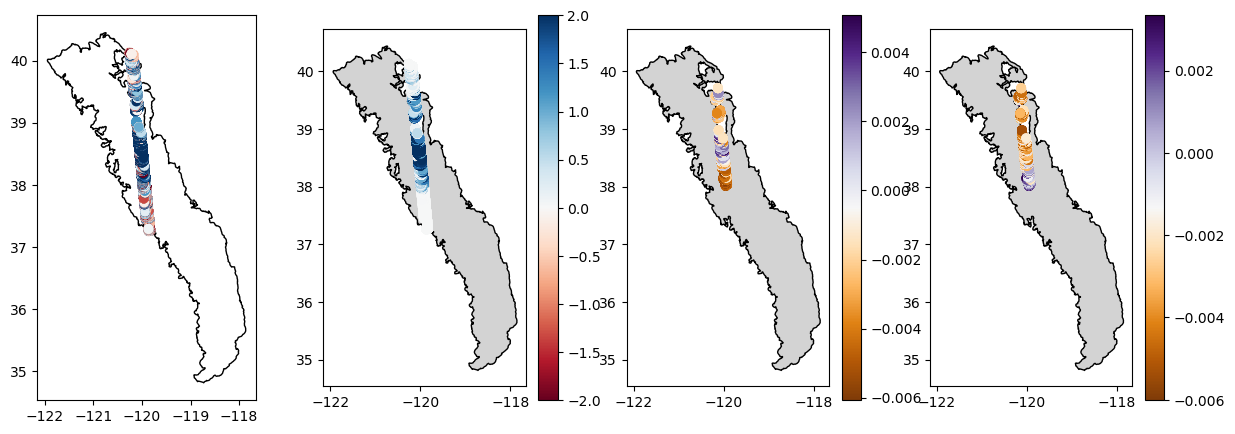

In [51]:
fig, ax = plt.subplots(1,4, figsize=(15,5))
sierras.plot(ax=ax[0], facecolor='none', edgecolor='k')
atl06sr_subset[atl06sr_subset['snow_presence']==1].plot(ax=ax[0], column='icesat2_3dep_dif',vmin=-2, vmax=2, cmap='RdBu')

sierras.plot(ax=ax[1], facecolor='lightgrey', edgecolor='k')
atl06sr_subset.plot(ax=ax[1], column='wy_2017', vmin=-2, vmax=2, cmap='RdBu', legend=True)

sierras.plot(ax=ax[2], facecolor='lightgrey', edgecolor='k')
atl06sr_subset.plot(ax=ax[2], column='eof2_weights', legend=True, cmap='PuOr')

sierras.plot(ax=ax[3], facecolor='lightgrey', edgecolor='k')
atl06sr_subset.plot(ax=ax[3], column='eof3_weights', legend=True, cmap='PuOr')

Text(0.5, 1.0, 'EOF 3 weights sampled at March 17 2019 ICESat-2 points')

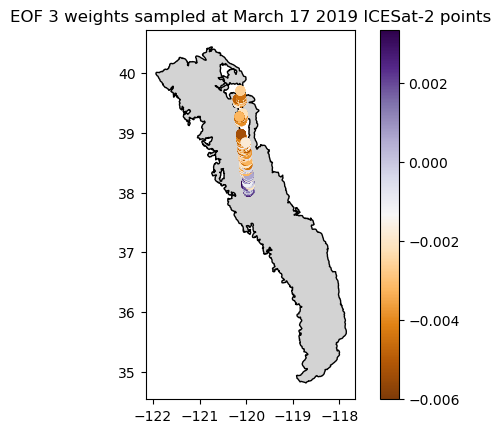

In [77]:
fig, ax = plt.subplots()
sierras.plot(ax=ax, facecolor='lightgrey', edgecolor='k')
atl06sr_subset.plot(ax=ax, column='eof3_weights', legend=True, cmap='PuOr')
plt.title('EOF 3 weights sampled at March 17 2019 ICESat-2 points')

Next steps:  
* restrict subset gdf to areas where eof weights are not nan 
* start with using eof 3 weights, since we know that was more important in 2019. 
    * use only icesat2 and sampled reanalysis points that have eof3 weights <0 (orange, north part of sierras).
    * Build the historical distribution by calculating the median snow depth for each year, then calculate mean and standard deviation of the sampled reanalysis 
    * Calculate the standardized anomaly of 2019 relative to the long term distribution 
    * calculate the mean and standard deviation at each reanalysis grid cell, using the same .where study region as I did for running the eof 
    * do another .where eof3 < 0 
    * for these grid cells, swe = icesat2_SA * gridcell_std + gridcell_mean 
    * calculate difference from the current year reanalysis for those grid cells

In [53]:
atl06sr_subset['eof3_weights']

time_ns
2019-03-17 16:05:58.552339968   NaN
2019-03-17 16:05:58.555159552   NaN
2019-03-17 16:05:58.979812608   NaN
2019-03-17 16:05:58.982648320   NaN
2019-03-17 16:05:58.985481728   NaN
                                 ..
2019-03-17 16:06:40.331458560   NaN
2019-03-17 16:06:40.334267392   NaN
2019-03-17 16:06:40.337075200   NaN
2019-03-17 16:06:40.339883776   NaN
2019-03-17 16:06:40.342691840   NaN
Name: eof3_weights, Length: 24886, dtype: float64

In [54]:
atl06sr_subset_eof3_neg = atl06sr_subset[atl06sr_subset['eof3_weights'] < 0]

<Axes: >

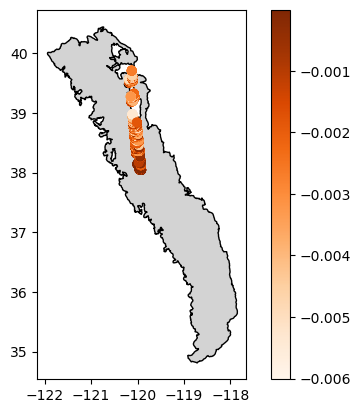

In [57]:
fig, ax = plt.subplots()
sierras.plot(ax=ax, facecolor='lightgrey', edgecolor='k')
atl06sr_subset_eof3_neg.plot(ax=ax, column='eof3_weights', cmap='Oranges', legend=True)

In [58]:
# Extract columns with 'wy_' prefix and compute median for each year
wy_cols = [col for col in atl06sr_subset_eof3_neg.columns if col.startswith('wy_')]
median_values = {col.replace('wy_', ''): atl06sr_subset_eof3_neg[col].median() for col in wy_cols}

# Create dataframe with water years as index
median_by_year_df = pd.DataFrame.from_dict(median_values, orient='index', columns=['median_sd'])
median_by_year_df.index.name = 'water_year'
median_by_year_df.index = median_by_year_df.index.astype(int)
median_by_year_df = median_by_year_df.sort_index()
median_by_year_df

,median_sd
water_year,
1985,0.811965
1986,2.454031
1987,0.853479
1988,0.642555
1989,1.144606
1990,1.239630
1991,1.265856
1992,1.142982
1993,2.794011


In [59]:
march172019_sd = atl06sr_subset_eof3_neg['icesat2_3dep_dif'].median()
march172019_sa = (march172019_sd - median_by_year_df['median_sd'].mean()) / median_by_year_df['median_sd'].std()

In [60]:
march172019_sa

np.float64(1.935342073345007)

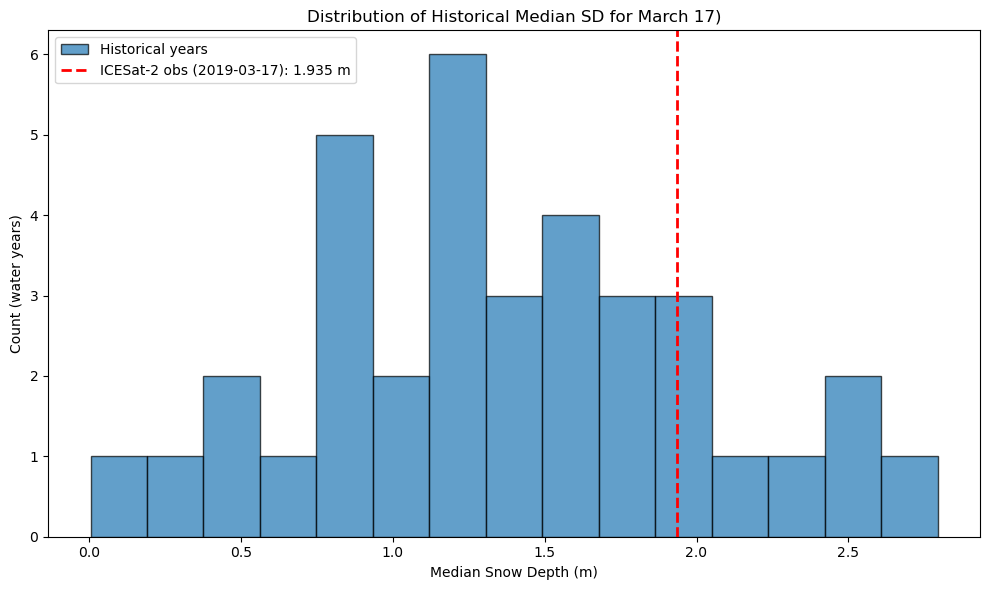


ICESat-2 observed median SD: 1.935 m
Historical mean: 1.367 m
Historical std: 0.640 m
Standardized anomaly: 2.61


In [64]:
# Plot histogram of historical median SD values with ICESat-2 observed value
fig, ax = plt.subplots(figsize=(10, 6))

# Histogram of historical median SD values
ax.hist(median_by_year_df['median_sd'].dropna(), bins=15, edgecolor='black', alpha=0.7, label='Historical years')

# Get the ICESat-2 observed value for 2019-03-17
#is2_value = medians_both.loc[medians_both['date'] == '2019-03-17', 'icesat2_3dep_dif'].values[0]

# Add vertical dashed line for ICESat-2 observation
ax.axvline(march172019_sa, color='red', linestyle='--', linewidth=2, label=f'ICESat-2 obs (2019-03-17): {march172019_sa:.3f} m')

# Add labels and legend
ax.set_xlabel('Median Snow Depth (m)')
ax.set_ylabel('Count (water years)')
ax.set_title(f'Distribution of Historical Median SD for March 17)')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nICESat-2 observed median SD: {march172019_sa:.3f} m")
print(f"Historical mean: {median_by_year_df['median_sd'].mean():.3f} m")
print(f"Historical std: {median_by_year_df['median_sd'].std():.3f} m")
print(f"Standardized anomaly: {march172019_sd:.2f}")

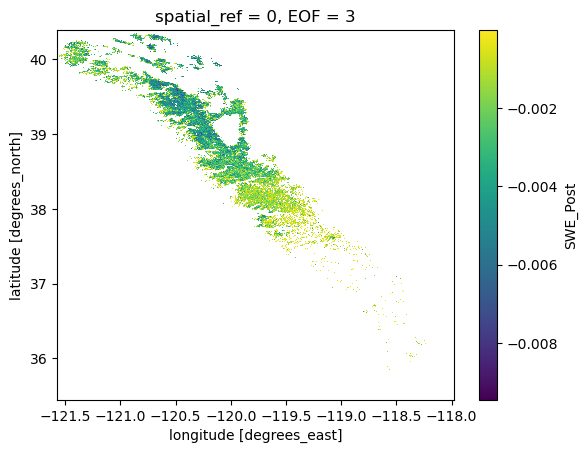

In [68]:
U_spatial_eof_anom.sel(EOF=3).where(U_spatial_eof_anom.sel(EOF=3) < 0).plot()

In [69]:
# Select only the date of interest in the snow depth data

# 1. Select March 17 of each year
sd_allyrs_march17 = swe_sca_ds_allyrs_sierras.SD_Post.sel(time=( (swe_sca_ds_allyrs_sierras['time'].dt.month == 3) & (swe_sca_ds_allyrs_sierras['time'].dt.day == 17) ))

# 2. Exclude 2019 from the calculations (that's the observation year)
sd_allyrs_march17_no2019 = sd_allyrs_march17.sel(time=sd_allyrs_march17['time'].dt.year != 2019)

# select only areas with eof3 < 0
sd_allyrs_march17_no2019_eof3neg = sd_allyrs_march17_no2019.where(U_spatial_eof_anom.sel(EOF=3) < 0)

# 3. Compute mean March 17 snow depth across years (excluding 2019)
sd_allyrs_march17_mean = sd_allyrs_march17_no2019_eof3neg.mean(dim='time', skipna=True).compute()

# 4. Compute standard deviation March 17 across years (excluding 2019)
sd_allyrs_march17_std = sd_allyrs_march17_no2019_eof3neg.std(dim='time', skipna=True).compute()

print(f"Years included in mean/std calculation: {sd_allyrs_march17_no2019_eof3neg['time'].dt.year.values}")

Years included in mean/std calculation: [1985 1986 1987 1988 1989 1990 1991 1992 1993 1994 1995 1996 1997 1998
 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012
 2013 2014 2015 2016 2017 2018 2020 2021]


In [71]:
march172019_sa

np.float64(1.935342073345007)

In [72]:
# Convert standardized anomaly back to snow depth: x = SA * std + mean

sa_sd_test_track = (march172019_sa * sd_allyrs_march17_std) + sd_allyrs_march17_mean

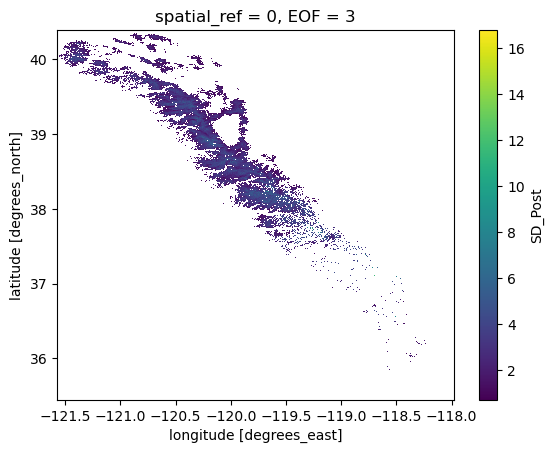

In [73]:
sa_sd_test_track.plot()

In [74]:
sa_sd_test_track_dif = (sa_sd_test_track - sd_ds_allyrs.SD_Post.sel(time='2019-03-17')).where(U_spatial_eof_anom.sel(EOF=3) < 0).compute()

Text(0.5, 1.0, 'Snow Depth from SA method on Mach 17 2019 where EOF3 < 0')

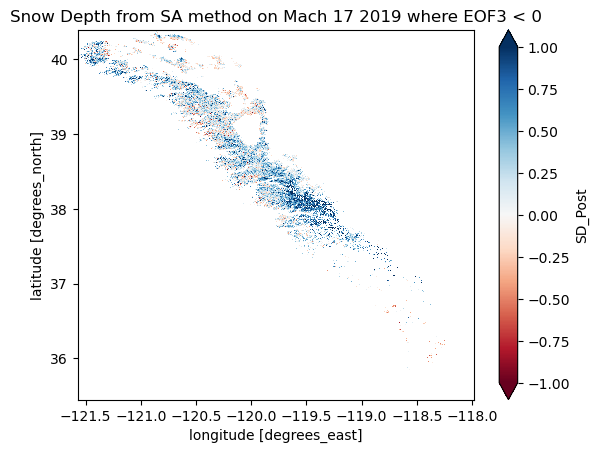

In [76]:
fig, ax = plt.subplots()
sa_sd_test_track_dif.plot(vmin=-1,vmax=1,cmap='RdBu')
plt.title('Snow Depth from SA method on Mach 17 2019 where EOF3 < 0')

### Run for the same date with positive e4of 3 values

In [78]:
atl06sr_subset_eof3_pos = atl06sr_subset[atl06sr_subset['eof3_weights'] > 0]

<Axes: >

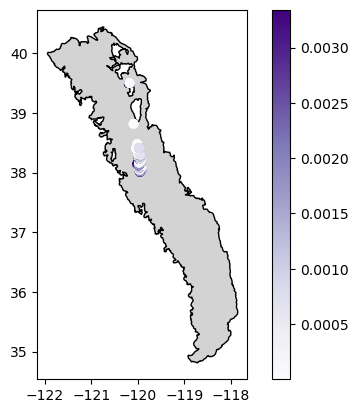

In [79]:
fig, ax = plt.subplots()
sierras.plot(ax=ax, facecolor='lightgrey', edgecolor='k')
atl06sr_subset_eof3_pos.plot(ax=ax, column='eof3_weights', cmap='Purples', legend=True)

In [80]:
atl06sr_subset_eof3_pos.shape

(1191, 87)

In [81]:
# Extract columns with 'wy_' prefix and compute median for each year
wy_cols = [col for col in atl06sr_subset_eof3_pos.columns if col.startswith('wy_')]
median_values = {col.replace('wy_', ''): atl06sr_subset_eof3_pos[col].median() for col in wy_cols}

# Create dataframe with water years as index
median_by_year_df = pd.DataFrame.from_dict(median_values, orient='index', columns=['median_sd'])
median_by_year_df.index.name = 'water_year'
median_by_year_df.index = median_by_year_df.index.astype(int)
median_by_year_df = median_by_year_df.sort_index()
median_by_year_df

,median_sd
water_year,
1985,0.393987
1986,1.087417
1987,0.305798
1988,0.131666
1989,0.486610
1990,0.444638
1991,1.059445
1992,0.960191
1993,1.928573


In [82]:
march172019_sd = atl06sr_subset_eof3_pos['icesat2_3dep_dif'].median()
march172019_sa = (march172019_sd - median_by_year_df['median_sd'].mean()) / median_by_year_df['median_sd'].std()

In [ ]:
march172019_sa

np.float64(1.935342073345007)

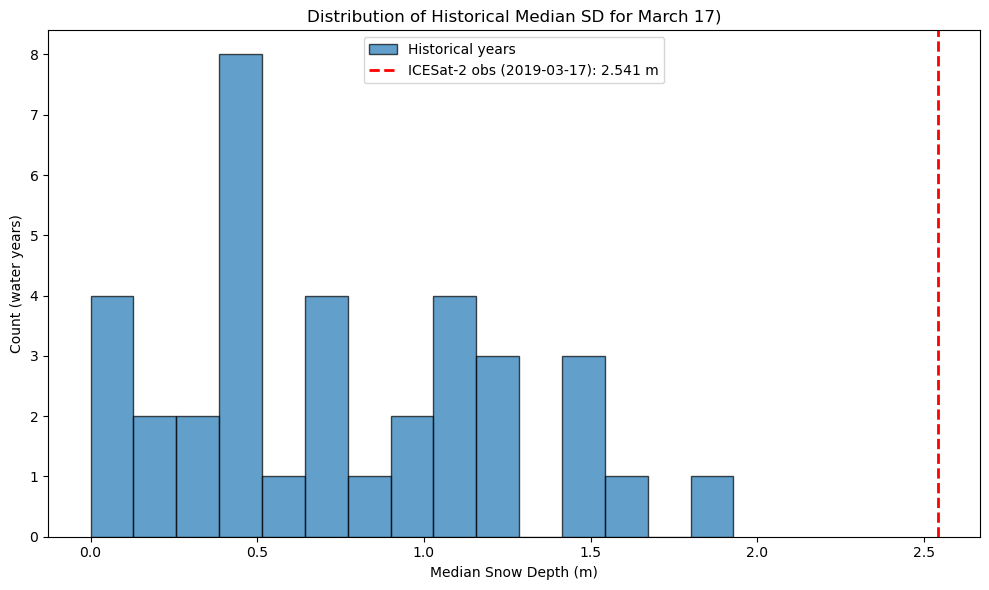


ICESat-2 observed median SD: 2.541 m
Historical mean: 0.750 m
Historical std: 0.497 m
Standardized anomaly: 2.01


In [83]:
# Plot histogram of historical median SD values with ICESat-2 observed value
fig, ax = plt.subplots(figsize=(10, 6))

# Histogram of historical median SD values
ax.hist(median_by_year_df['median_sd'].dropna(), bins=15, edgecolor='black', alpha=0.7, label='Historical years')

# Get the ICESat-2 observed value for 2019-03-17
#is2_value = medians_both.loc[medians_both['date'] == '2019-03-17', 'icesat2_3dep_dif'].values[0]

# Add vertical dashed line for ICESat-2 observation
ax.axvline(march172019_sa, color='red', linestyle='--', linewidth=2, label=f'ICESat-2 obs (2019-03-17): {march172019_sa:.3f} m')

# Add labels and legend
ax.set_xlabel('Median Snow Depth (m)')
ax.set_ylabel('Count (water years)')
ax.set_title(f'Distribution of Historical Median SD for March 17)')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nICESat-2 observed median SD: {march172019_sa:.3f} m")
print(f"Historical mean: {median_by_year_df['median_sd'].mean():.3f} m")
print(f"Historical std: {median_by_year_df['median_sd'].std():.3f} m")
print(f"Standardized anomaly: {march172019_sd:.2f}")

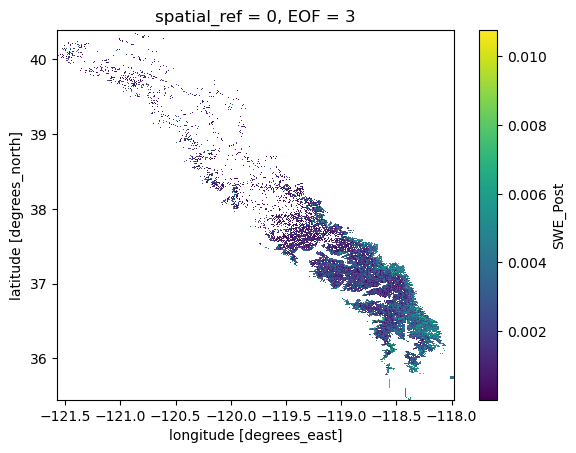

In [85]:
U_spatial_eof_anom.sel(EOF=3).where(U_spatial_eof_anom.sel(EOF=3) > 0).plot()

In [86]:
# Select only the date of interest in the snow depth data

# 1. Select March 17 of each year
sd_allyrs_march17 = swe_sca_ds_allyrs_sierras.SD_Post.sel(time=( (swe_sca_ds_allyrs_sierras['time'].dt.month == 3) & (swe_sca_ds_allyrs_sierras['time'].dt.day == 17) ))

# 2. Exclude 2019 from the calculations (that's the observation year)
sd_allyrs_march17_no2019 = sd_allyrs_march17.sel(time=sd_allyrs_march17['time'].dt.year != 2019)

# select only areas with eof3 > 0
sd_allyrs_march17_no2019_eof3pos = sd_allyrs_march17_no2019.where(U_spatial_eof_anom.sel(EOF=3) > 0)

# 3. Compute mean March 17 snow depth across years (excluding 2019)
sd_allyrs_march17_mean = sd_allyrs_march17_no2019_eof3pos.mean(dim='time', skipna=True).compute()

# 4. Compute standard deviation March 17 across years (excluding 2019)
sd_allyrs_march17_std = sd_allyrs_march17_no2019_eof3pos.std(dim='time', skipna=True).compute()

print(f"Years included in mean/std calculation: {sd_allyrs_march17_no2019_eof3pos['time'].dt.year.values}")

Years included in mean/std calculation: [1985 1986 1987 1988 1989 1990 1991 1992 1993 1994 1995 1996 1997 1998
 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012
 2013 2014 2015 2016 2017 2018 2020 2021]


In [87]:
march172019_sa

np.float64(2.541256924779452)

In [88]:
# Convert standardized anomaly back to snow depth: x = SA * std + mean

sa_sd_test_track = (march172019_sa * sd_allyrs_march17_std) + sd_allyrs_march17_mean

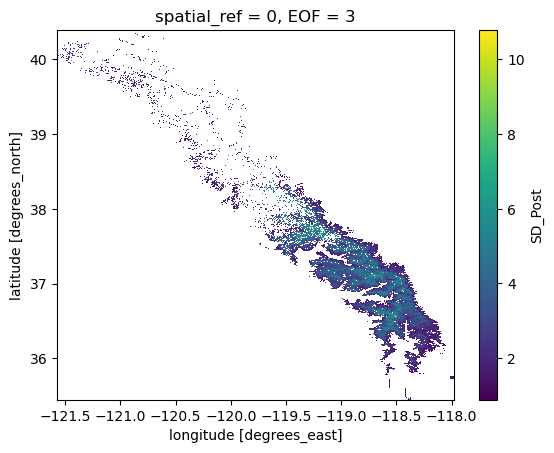

In [89]:
sa_sd_test_track.plot()

In [90]:
sa_sd_test_track_dif = (sa_sd_test_track - sd_ds_allyrs.SD_Post.sel(time='2019-03-17')).where(U_spatial_eof_anom.sel(EOF=3) > 0).compute()

Text(0.5, 1.0, 'Snow Depth Difference from SA method on Mach 17 2019 where EOF3 > 0')

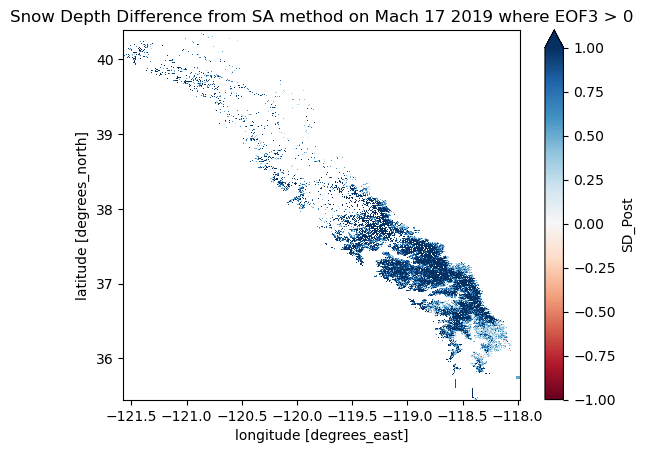

In [93]:
fig, ax = plt.subplots()
sa_sd_test_track_dif.plot(vmin=-1,vmax=1,cmap='RdBu')
plt.title('Snow Depth Difference from SA method on Mach 17 2019 where EOF3 > 0')